# Introduction

## Purpose

_Created by Romain Molins, with support from Philip Bradstock from Bitbloom_

This notebook has been developed to generate long-term Production Time Series from a few years (minimum one) of OYA PTS

On Knowledge Share:


## Version History

- 1.0: Base version

## Loading Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
from IPython.display import FileLink
import re

import scipy
from scipy.stats import loguniform, uniform, randint
from functools import partial
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay

from sklearn.model_selection import cross_val_predict, KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

from cmethods import adjust

## Functions

In [2]:
_NanosecondsInDay = 24 * 3600 * 10**9
_NanosecondsInYear = 365.2425 * _NanosecondsInDay

#do you want the graphsd in 3.2 to be enabled or not
inspection = False

def _get_radians(timestamps: pd.DatetimeIndex, period):
    if period == 'day':
        return 2 * np.pi * np.mod(timestamps.astype(np.int64) / _NanosecondsInDay, 1.0)
    if period == 'year':
        return 2 * np.pi * np.mod(timestamps.astype(np.int64) / _NanosecondsInYear, 1.0)


def get_time_comps(data, period):
    data_radians = _get_radians(data, period)
    return np.cos(data_radians), np.sin(data_radians)

# is added below as it corresponds to the wind speed column, so we focus on wind speed metric. This is dirty, should be cleaned later
def binned_error(y_true, y_pred, bins_0=None):
    # Precompute bins if not provided
    if bins_0 is None:
        bins_0 = np.arange(0.0, y_true.max() , 1)
    # Compute histograms
    pred_freq, _ = np.histogram(y_pred, bins=bins_0)
    train_freq, _ = np.histogram(y_true, bins=bins_0)
    # Normalize (avoid division by zero)
    pred_sum = pred_freq.sum()
    train_sum = train_freq.sum()
    if pred_sum == 0 or train_sum == 0:
        return np.nan
    pred_freq = pred_freq / pred_sum
    train_freq = train_freq / train_sum
    # Use mean_absolute_error directly (train_freq.mean() is 1)
    return mean_absolute_error(train_freq, pred_freq)

#this one combines the previous error with the RMSE classic error, summing them
def overall_score(y_true, y_pred):
    bin_error = binned_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred)) / y_true.max()
    return bin_error + rmse

## User Input

In [3]:
#Define timezone
time_zone_reference = 'Etc/GMT+2'
time_zone_site = 'Etc/GMT+2'
time_zone_output = 'Etc/GMT+2'

project = 'Waaihoek'

# path of input reference timeseries file that will be used as X
reference_file = "../vortex.times.864091.20y 100m UTC+02.0 ERA5.txt"

#reference data period
reference_start_date = '2005-01-01 00:00'
reference_end_date = '2025-05-30 23:50'

# path of input onsite timeseries file that will be used as Y.
onsite_file = "../SA014_02_clean_cmbAno_2025 100m.txt"

#training period - usually the period of the OYA PTS
start_training = '2016-01-01 00:00'
end_training = '2016-12-31 23:50'

#testing period - usually the period of the OYA PTS
start_testing = '2017-01-01 00:00'
end_testing = '2017-12-31 23:50'

#prediction period - or long-term period required for the output - cannot be great than the vortex dates
start_pred_LT = '2005-01-01 00:00'
end_pred_LT = '2025-05-30 23:50'

#reference nodes
v_wsnode = 'M(m/s)'
v_wdnode = 'D(deg)'
v_adnode = 'De(k/m3)'
v_RInode = 'RiNumber'
v_tnode = 'T(C)'
v_pnode = 'PRE(hPa)'

#onsite nodes
o_wsnode = 'Speed 100m cmb [m/s]'
o_wdnode = 'Wind Direction 97.90m S avg [°]'


# Loading data

## Load Vortex

In [4]:
#raw Vortex SERIES format below
vortex_data = pd.read_fwf(reference_file, skiprows=3,parse_dates=[['YYYYMMDD', 'HHMM']], index_col=0)
vortex_data.index = vortex_data.index.tz_localize(time_zone_reference)

#go from polar to cartesian
vortex_data['cos_u'] = np.cos(np.deg2rad(vortex_data[v_wdnode])) * vortex_data[v_wsnode]
vortex_data['sin_u'] = np.sin(np.deg2rad(vortex_data[v_wdnode])) * vortex_data[v_wsnode]

#then conver hour and month to polar domain, to facilitate ML training (as months and hours are cyclical)
year_cos, year_sin = get_time_comps(vortex_data.index, 'year')
vortex_data['time_of_year_cos'] = year_cos
vortex_data['time_of_year_sin'] = year_sin

day_cos, day_sin = get_time_comps(vortex_data.index, 'day')
vortex_data['time_of_day_cos'] = day_cos
vortex_data['time_of_day_sin'] = day_sin

#trim to start/end
vortex_data = vortex_data.loc[reference_start_date:reference_end_date,:].copy()
vortex_data

,M(m/s),D(deg),SD(m/s),T(C),De(k/m3),PRE(hPa),RiNumber,RH(%),RMOL(1/m),VertM(m/s),cos_u,sin_u,time_of_year_cos,time_of_year_sin,time_of_day_cos,time_of_day_sin
YYYYMMDD_HHMM,,,,,,,,,,,,,,,,
2005-01-01 02:00:00-02:00,4.94,114.5,0.46,13.2,1.01,831.0,3.15,100.0,-0.0090,-0.03,-2.048585,4.495209,0.999932,0.011683,0.500000,0.866025
2005-01-01 02:10:00-02:00,4.25,115.7,0.51,13.2,1.01,831.0,12.58,100.0,-0.0107,0.01,-1.843051,3.829577,0.999930,0.011803,0.461749,0.887011
2005-01-01 02:20:00-02:00,4.15,101.1,0.49,13.7,1.01,831.0,0.38,100.0,-0.0105,-0.13,-0.798966,4.072365,0.999929,0.011922,0.422618,0.906308
2005-01-01 02:30:00-02:00,3.11,110.4,0.52,13.0,1.01,831.1,78.49,100.0,-0.0107,0.06,-1.084059,2.914947,0.999927,0.012042,0.382683,0.923880
2005-01-01 02:40:00-02:00,5.54,101.5,0.43,13.7,1.01,831.1,1.87,100.0,-0.0100,0.28,-1.104498,5.428783,0.999926,0.012161,0.342020,0.939693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-30 23:10:00-02:00,5.56,12.6,0.54,8.1,1.04,836.0,0.54,98.7,0.0393,-0.30,5.426097,1.212876,-0.853077,0.521786,0.953717,0.300706
2025-05-30 23:20:00-02:00,5.53,2.3,0.23,8.1,1.04,836.1,0.81,96.9,0.0468,-0.07,5.525545,0.221929,-0.853139,0.521684,0.939693,0.342020
2025-05-30 23:30:00-02:00,5.69,355.8,0.35,8.6,1.03,836.1,2.40,93.9,0.0553,-0.09,5.674719,-0.416725,-0.853201,0.521582,0.923880,0.382683


## Load site data

In [6]:
#onsite data
onsite_data = pd.read_csv(onsite_file, sep=",", parse_dates=True, index_col=0, skiprows=14, dayfirst=False)
onsite_data.index = onsite_data.index.tz_localize(time_zone_site)

#trim to start/end
#onsite_data = onsite_data.loc[start_training:end_training,:].copy()
onsite_data['o_cos_u'] =  np.cos(np.deg2rad(onsite_data[o_wdnode])) * onsite_data[o_wsnode]
onsite_data['o_sin_u'] =  np.sin(np.deg2rad(onsite_data[o_wdnode])) * onsite_data[o_wsnode]

onsite_data

,Pressure 80.00m N avg [hPa],Relative Humidity 90.00m N avg [%],Temperature 90.00m N avg [°C],Wind Direction 97.90m S avg [°],Speed 100m cmb [m/s],Speed 100m cmb SD [m/s],o_cos_u,o_sin_u
Timestamp (UTC+02),,,,,,,,
2014-05-13 15:10:00-02:00,841.0,55.5,NaN,65.8,2.709,0.462,1.110481,2.470933
2014-05-13 15:20:00-02:00,838.0,55.7,NaN,52.4,2.868,0.650,1.749896,2.272287
2014-05-13 15:30:00-02:00,838.0,55.6,NaN,67.3,2.905,0.653,1.121057,2.679973
2014-05-13 15:40:00-02:00,838.0,55.8,NaN,69.4,2.939,0.738,1.034063,2.751079
2014-05-13 15:50:00-02:00,838.0,55.8,NaN,84.3,3.035,0.768,0.301435,3.019994
...,...,...,...,...,...,...,...,...
2025-02-04 10:50:00-02:00,846.0,64.3,24.00,305.2,3.555,0.937,2.049217,-2.904950
2025-02-04 11:00:00-02:00,846.0,64.2,24.05,303.6,3.729,0.828,2.063597,-3.105963
2025-02-04 11:10:00-02:00,846.0,63.3,24.28,300.1,3.508,0.773,1.759300,-3.034951


# ML Model

## Baseline Model

In [7]:
#columns used for Vortex (X) model
columnsX = ['cos_u','sin_u', v_tnode, v_pnode, 'time_of_day_cos', 'time_of_day_sin','time_of_year_cos', 'time_of_year_sin']
#columns for postprocessing
columnsX_ps = [v_wsnode, v_wdnode]

#columns for training
columnsY = ['o_cos_u', 'o_sin_u']
#columns for postprocessing
columnsY_ps = [o_wsnode, o_wdnode]


#we merge to align on the same timestamps and avoid gaps
data_train = vortex_data.loc[start_training:end_training,columnsX+columnsX_ps].merge(onsite_data.loc[start_training:end_training,columnsY+columnsY_ps],how='outer',left_index=True, right_index=True)

#remove empty rows with missing values - no nan can be in the training data
data_train = data_train.dropna(axis=0, how='any')

#define X and y
X_train = data_train.loc[start_training:end_training,columnsX]
y_train = data_train.loc[start_training:end_training,columnsY]


In [8]:
#now we set up the core model
model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        loss='squared_error',
        hidden_layer_sizes = (100,),
        activation='relu',
        solver='adam',
        alpha=1E-0,
        max_iter=1000
    ),
)

model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('mlpregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'


In [9]:
#and we create the y predicted for testing period
X_pred_testing = vortex_data.loc[start_testing:end_testing,columnsX]
y_pred_testing = model.predict(X_pred_testing)

#just some postprocessing to convert the output to dataframe and CSV output
y_pred_testing = pd.DataFrame(index=vortex_data.loc[start_testing:end_testing,:].index, data=y_pred_testing,columns=columnsY)
y_pred_testing[o_wsnode] = np.sqrt(y_pred_testing['o_cos_u']**2 + y_pred_testing['o_sin_u']**2)
y_pred_testing[o_wdnode] = np.mod(np.rad2deg(np.arctan2(y_pred_testing['o_sin_u'], y_pred_testing['o_cos_u'])),360)

y_pred_testing

,o_cos_u,o_sin_u,Speed 100m cmb [m/s],Wind Direction 97.90m S avg [°]
YYYYMMDD_HHMM,,,,
2017-01-01 00:00:00-02:00,4.901010,0.433179,4.920116,5.050995
2017-01-01 00:10:00-02:00,4.323688,-0.205238,4.328556,357.282314
2017-01-01 00:20:00-02:00,3.545323,-0.983240,3.679141,344.499475
2017-01-01 00:30:00-02:00,3.289270,-1.645548,3.677924,333.422227
2017-01-01 00:40:00-02:00,2.549799,-1.636330,3.029695,327.309737
...,...,...,...,...
2017-12-31 23:10:00-02:00,6.363306,-1.236755,6.482378,349.001269
2017-12-31 23:20:00-02:00,6.303927,-0.767633,6.350493,353.057239
2017-12-31 23:30:00-02:00,6.548967,-0.662635,6.582405,354.222382


In [10]:
y_test = onsite_data.loc[start_testing:end_testing,columnsY_ps].copy()
y_test

,Speed 100m cmb [m/s],Wind Direction 97.90m S avg [°]
Timestamp (UTC+02),,
2017-01-01 00:00:00-02:00,5.214,8.8
2017-01-01 00:10:00-02:00,4.032,15.6
2017-01-01 00:20:00-02:00,3.005,0.5
2017-01-01 00:30:00-02:00,2.594,359.4
2017-01-01 00:40:00-02:00,1.528,354.3
...,...,...
2017-12-31 23:10:00-02:00,NaN,NaN
2017-12-31 23:20:00-02:00,NaN,NaN
2017-12-31 23:30:00-02:00,NaN,NaN


In [11]:
#remove NANs!
test_merge = y_pred_testing.merge(y_test, left_index=True, right_index=True,suffixes= ('', '_Original'))
test_merge.dropna(inplace=True)
y_pred_testing = test_merge[[o_wsnode, o_wdnode]].copy()
y_test = test_merge[[o_wsnode+'_Original', o_wdnode+'_Original']].copy()
y_test.columns = y_test.columns.str.removesuffix('_Original')

In [12]:
y_test

,Speed 100m cmb [m/s],Wind Direction 97.90m S avg [°]
YYYYMMDD_HHMM,,
2017-01-01 00:00:00-02:00,5.214,8.8
2017-01-01 00:10:00-02:00,4.032,15.6
2017-01-01 00:20:00-02:00,3.005,0.5
2017-01-01 00:30:00-02:00,2.594,359.4
2017-01-01 00:40:00-02:00,1.528,354.3
...,...,...
2017-12-31 19:30:00-02:00,11.111,28.6
2017-12-31 19:40:00-02:00,11.861,26.4
2017-12-31 19:50:00-02:00,13.257,18.1


In [13]:
y_pred_testing

,Speed 100m cmb [m/s],Wind Direction 97.90m S avg [°]
YYYYMMDD_HHMM,,
2017-01-01 00:00:00-02:00,4.920116,5.050995
2017-01-01 00:10:00-02:00,4.328556,357.282314
2017-01-01 00:20:00-02:00,3.679141,344.499475
2017-01-01 00:30:00-02:00,3.677924,333.422227
2017-01-01 00:40:00-02:00,3.029695,327.309737
...,...,...
2017-12-31 19:30:00-02:00,6.565134,20.913894
2017-12-31 19:40:00-02:00,6.830302,12.280463
2017-12-31 19:50:00-02:00,6.655490,9.778797


## Scoring

In [14]:
#we give example of both error values using the previous baseline models - wind speed
overall_score_best = overall_score(y_test[o_wsnode].to_numpy(), y_pred_testing[o_wsnode].to_numpy())
binned_error_best = binned_error(y_test[o_wsnode].to_numpy(), y_pred_testing[o_wsnode].to_numpy())
best_score_best = 100 * sqrt(mean_squared_error(y_test[o_wsnode], y_pred_testing[o_wsnode])) / y_test[o_wsnode].max()
print(f'Wind speed score is {best_score_best:.2f}% ')
print(f'Wind speed binned error is {100*binned_error_best:.2f}% ')
print(f'Wind speed overall error is  {100*overall_score_best:.2f}% ')

Wind speed score is 8.00% 
Wind speed binned error is 0.79% 
Wind speed overall error is  8.79% 


In [15]:
#we give example of both error values using the previous baseline models - wind direction
overall_score_best = overall_score(y_test[o_wdnode].to_numpy(), y_pred_testing[o_wdnode].to_numpy())
binned_error_best = binned_error(y_test[o_wdnode].to_numpy(), y_pred_testing[o_wdnode].to_numpy())
best_score_best = 100 * sqrt(mean_squared_error(y_test[o_wdnode], y_pred_testing[o_wdnode])) / y_test[o_wdnode].max()
print(f'Wind speed score is {best_score_best:.2f}% ')
print(f'Wind speed binned error is {100*binned_error_best:.2f}% ')
print(f'Wind speed overall error is  {100*overall_score_best:.2f}% ')

Wind speed score is 24.88% 
Wind speed binned error is 0.05% 
Wind speed overall error is  24.93% 


## Inspection

In [16]:
if inspection:
    common_params = {
        #"subsample": 50,
        "n_jobs": -5,
    }
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title("Multi-layer Perceptron")
    mlp_disp = PartialDependenceDisplay.from_estimator(
        model, X_train, columnsX, ax=ax, line_kw={"color": "red"}, **common_params
    )

In [17]:
if inspection:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title("Multi-layer Perceptron")
    mlp_disp = PartialDependenceDisplay.from_estimator(
        model, X_train, columnsX, kind='both', ax=ax, line_kw={"color": "red"}, **common_params
    )

## LT Prediction

In [18]:
#and we predict it
X_pred_LT = vortex_data.loc[start_pred_LT:end_pred_LT,columnsX]
X_pred_LT.replace([np.inf, -np.inf], 0, inplace=True)

#X_pred_LT = np.nan_to_num(X_pred_LT) #to avoid nans at beginning and end due to t+1/t-1
y_pred_LT = model.predict(X_pred_LT)

#just some postprocessing to convert the output to dataframe and CSV output
WS_lt = pd.DataFrame(index=vortex_data.loc[start_pred_LT:end_pred_LT,:].index, data=y_pred_LT,columns=columnsY)

#from cartesian to polar
WS_lt[o_wsnode] = np.sqrt(WS_lt['o_cos_u']**2 + WS_lt['o_sin_u']**2)
WS_lt[o_wdnode] = np.mod(np.rad2deg(np.arctan2(WS_lt['o_sin_u'], WS_lt['o_cos_u'])),360)

WS_lt

,o_cos_u,o_sin_u,Speed 100m cmb [m/s],Wind Direction 97.90m S avg [°]
YYYYMMDD_HHMM,,,,
2005-01-01 02:00:00-02:00,-0.736621,6.902535,6.941729,96.091404
2005-01-01 02:10:00-02:00,-0.568624,6.449485,6.474503,95.038499
2005-01-01 02:20:00-02:00,0.229176,5.925590,5.930020,87.785154
2005-01-01 02:30:00-02:00,0.041835,5.698832,5.698986,89.579402
2005-01-01 02:40:00-02:00,-0.067295,6.613921,6.614264,90.582951
...,...,...,...,...
2025-05-30 23:10:00-02:00,5.198324,1.897827,5.533924,20.056346
2025-05-30 23:20:00-02:00,5.374800,1.384459,5.550243,14.444444
2025-05-30 23:30:00-02:00,5.650407,0.971653,5.733342,9.757240


# Validation

In the previous 'Scoring' sectiosn we focused on ML metrics to define the best model 
Here as complement we validate the model and ensure that the LT PTS distribution, hourly/monthly/yearly profiles and frequency patterns makes sense compared to the OYA PTS and Vortex data

In [19]:
data_predict_train = WS_lt.loc[start_training:end_training,columnsY_ps].merge(onsite_data.loc[start_training:end_training,columnsY_ps],how='inner',left_index=True, right_index=True,suffixes= ('_Predicted', '_Original') )
data_predict_train.dropna(inplace=True)
y_predict_train = data_predict_train.loc[start_training:end_training,[l + '_Predicted' for l in columnsY_ps]].copy()
y_predict_train

,Speed 100m cmb [m/s]_Predicted,Wind Direction 97.90m S avg [°]_Predicted
YYYYMMDD_HHMM,,
2016-01-01 00:00:00-02:00,5.920208,25.245858
2016-01-01 00:10:00-02:00,5.529574,25.758308
2016-01-01 00:20:00-02:00,5.729182,23.854601
2016-01-01 00:30:00-02:00,5.477211,24.278110
2016-01-01 00:40:00-02:00,5.555982,19.564394
...,...,...
2016-12-31 23:10:00-02:00,6.104589,11.973491
2016-12-31 23:20:00-02:00,6.106740,13.469749
2016-12-31 23:30:00-02:00,6.000190,8.039390


In [20]:
data_predict_test = WS_lt.loc[start_testing:end_testing,columnsY_ps].merge(onsite_data.loc[start_testing:end_testing,columnsY_ps],how='inner',left_index=True, right_index=True,suffixes= ('_Predicted', '_Original') )
data_predict_test.dropna(inplace=True)
y_predict_test = data_predict_test.loc[start_testing:end_testing,[l + '_Predicted' for l in columnsY_ps]].copy()
y_predict_test

,Speed 100m cmb [m/s]_Predicted,Wind Direction 97.90m S avg [°]_Predicted
YYYYMMDD_HHMM,,
2017-01-01 00:00:00-02:00,4.920116,5.050995
2017-01-01 00:10:00-02:00,4.328556,357.282314
2017-01-01 00:20:00-02:00,3.679141,344.499475
2017-01-01 00:30:00-02:00,3.677924,333.422227
2017-01-01 00:40:00-02:00,3.029695,327.309737
...,...,...
2017-12-31 19:30:00-02:00,6.565134,20.913894
2017-12-31 19:40:00-02:00,6.830302,12.280463
2017-12-31 19:50:00-02:00,6.655490,9.778797


## Scatter Plot

In [21]:
#we calculate back the wind speed if missing
data_train[v_wsnode] = np.sqrt(data_train['cos_u']**2 + data_train['sin_u']**2) 

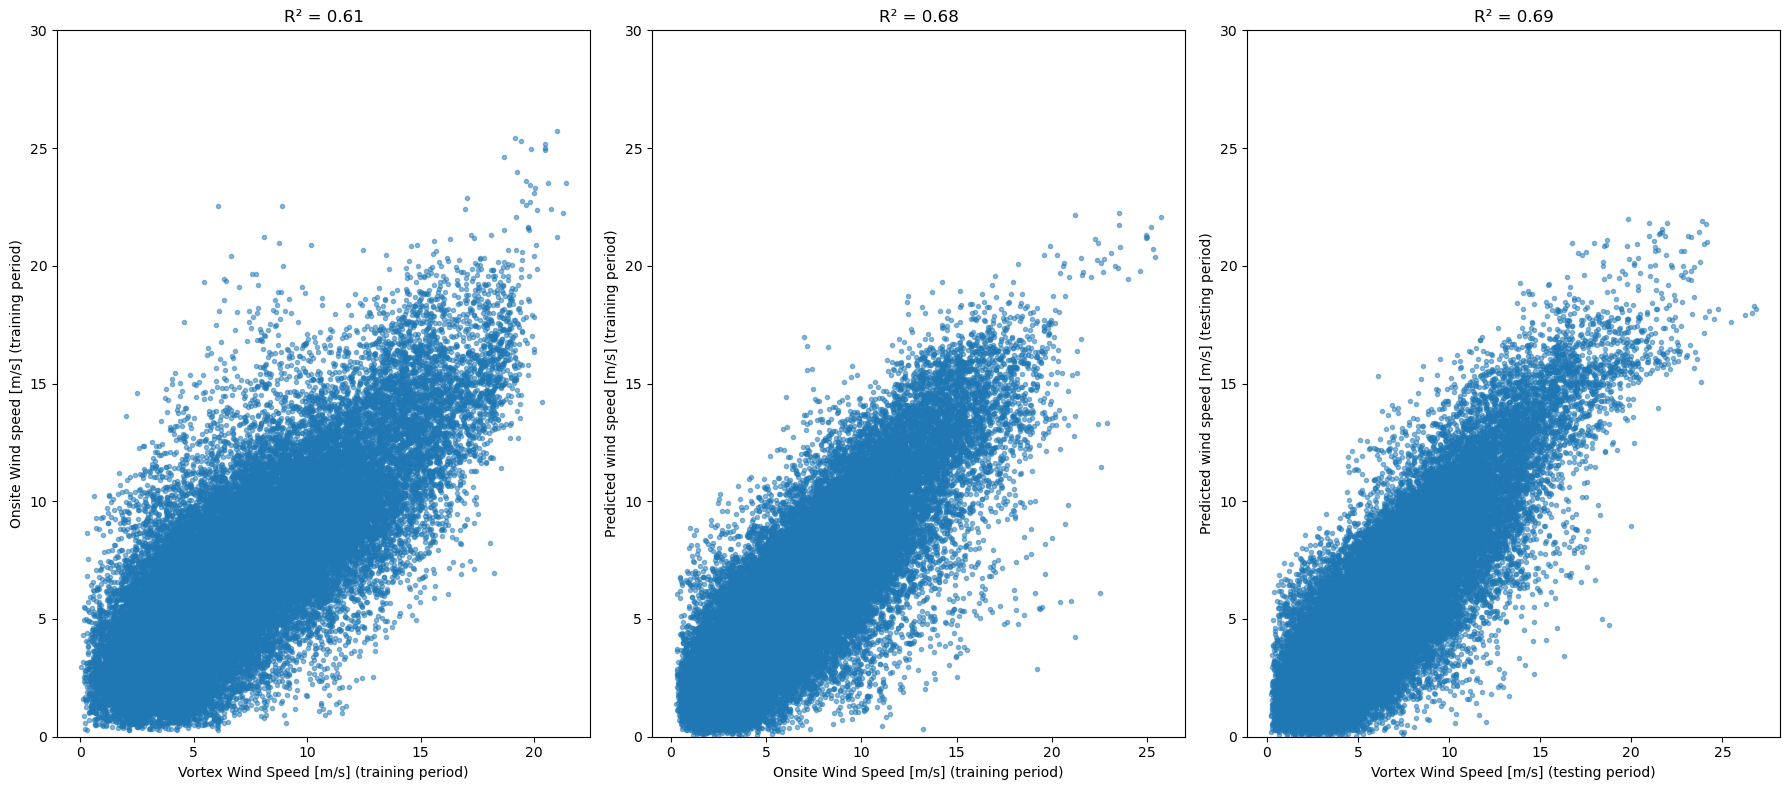

In [22]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 8))

ylim = (0, 30)

# 1st plot: ws vs y_train
#r2_score is not equal to pearson squared for any fit that is non linear!
#r2_1 = r2_score(data_train['ws scaled'], data_train[o_wsnode])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_train[v_wsnode], data_train[o_wsnode])
r2_1 = r_value**2

ax[0].scatter(data_train[v_wsnode], data_train[o_wsnode], marker='.', alpha=0.5)
ax[0].set_xlabel('Vortex Wind Speed [m/s] (training period)')
ax[0].set_ylabel('Onsite Wind speed [m/s] (training period)')
ax[0].set_ylim(*ylim)
ax[0].set_title(f'R² = {r2_1:.2f}')

# 2nd plot: ws vs best_y_pred
#r2_2 = r2_score(data_predict_train.iloc[:,0], data_predict_train.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_train[o_wsnode+'_Original'], data_predict_train[o_wsnode+'_Predicted'])
r2_2 = r_value**2

ax[1].scatter(data_predict_train[o_wsnode+'_Original'],data_predict_train[o_wsnode+'_Predicted'], marker='.', alpha=0.5)
ax[1].set_xlabel('Onsite Wind Speed [m/s] (training period)')
ax[1].set_ylabel('Predicted wind speed [m/s] (training period)')
ax[1].set_ylim(*ylim)
ax[1].set_title(f'R² = {r2_2:.2f}')


# 3nd plot: test period
#r2_3 = r2_score(data_predict_test.iloc[:,0], data_predict_test.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_test[o_wsnode+'_Original'], data_predict_test[o_wsnode+'_Predicted'])
r2_3 = r_value**2

ax[2].scatter(data_predict_test[o_wsnode+'_Original'], data_predict_test[o_wsnode+'_Predicted'], marker='.', alpha=0.5)
ax[2].set_xlabel('Vortex Wind Speed [m/s] (testing period)')
ax[2].set_ylabel('Predicted wind speed [m/s] (testing period)')
ax[2].set_ylim(*ylim)
ax[2].set_title(f'R² = {r2_3:.2f}')


plt.tight_layout()
plt.show()

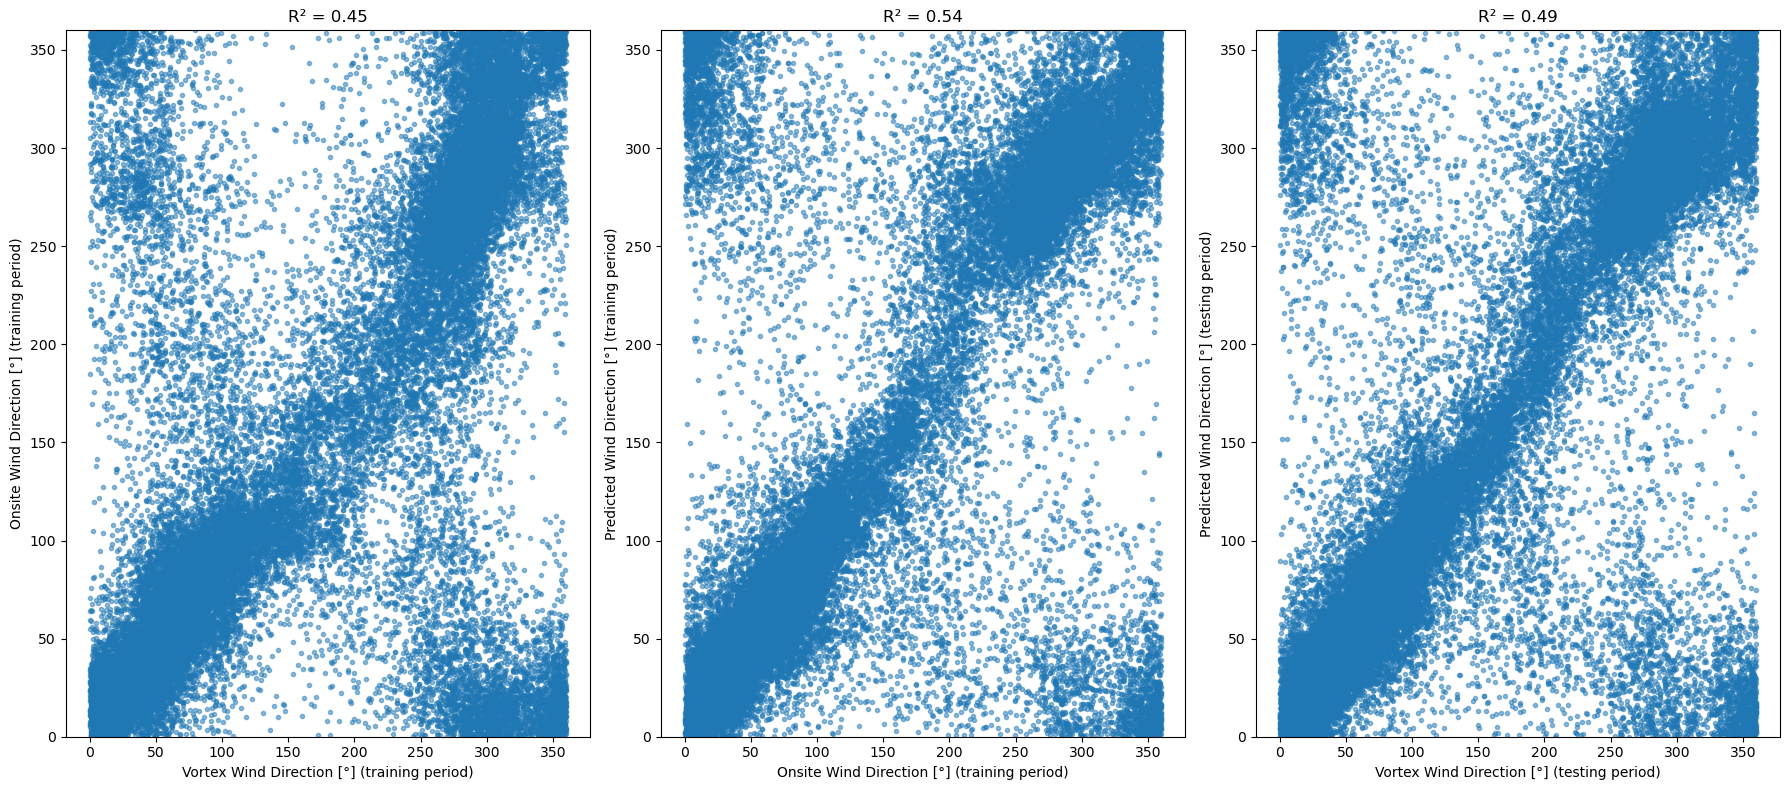

In [23]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 8))

ylim = (0, 360)

# 1st plot: ws vs y_train
#r2_score is not equal to pearson squared for any fit that is non linear!
#r2_1 = r2_score(data_train['ws scaled'], data_train[o_wdnode])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_train[v_wdnode], data_train[o_wdnode])
r2_1 = r_value**2

ax[0].scatter(data_train[v_wdnode], data_train[o_wdnode], marker='.', alpha=0.5)
ax[0].set_xlabel('Vortex Wind Direction [°] (training period)')
ax[0].set_ylabel('Onsite Wind Direction [°] (training period)')
ax[0].set_ylim(*ylim)
ax[0].set_title(f'R² = {r2_1:.2f}')

# 2nd plot: ws vs best_y_pred
#r2_2 = r2_score(data_predict_train.iloc[:,0], data_predict_train.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_train[o_wdnode+'_Original'], data_predict_train[o_wdnode+'_Predicted'])
r2_2 = r_value**2

ax[1].scatter(data_predict_train[o_wdnode+'_Original'],data_predict_train[o_wdnode+'_Predicted'], marker='.', alpha=0.5)
ax[1].set_xlabel('Onsite Wind Direction [°] (training period)')
ax[1].set_ylabel('Predicted Wind Direction [°] (training period)')
ax[1].set_ylim(*ylim)
ax[1].set_title(f'R² = {r2_2:.2f}')


# 3nd plot: test period
#r2_3 = r2_score(data_predict_test.iloc[:,0], data_predict_test.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_test[o_wdnode+'_Original'], data_predict_test[o_wdnode+'_Predicted'])
r2_3 = r_value**2

ax[2].scatter(data_predict_test[o_wdnode+'_Original'], data_predict_test[o_wdnode+'_Predicted'], marker='.', alpha=0.5)
ax[2].set_xlabel('Vortex Wind Direction [°] (testing period)')
ax[2].set_ylabel('Predicted Wind Direction [°] (testing period)')
ax[2].set_ylim(*ylim)
ax[2].set_title(f'R² = {r2_3:.2f}')


plt.tight_layout()
plt.show()

## Histogram

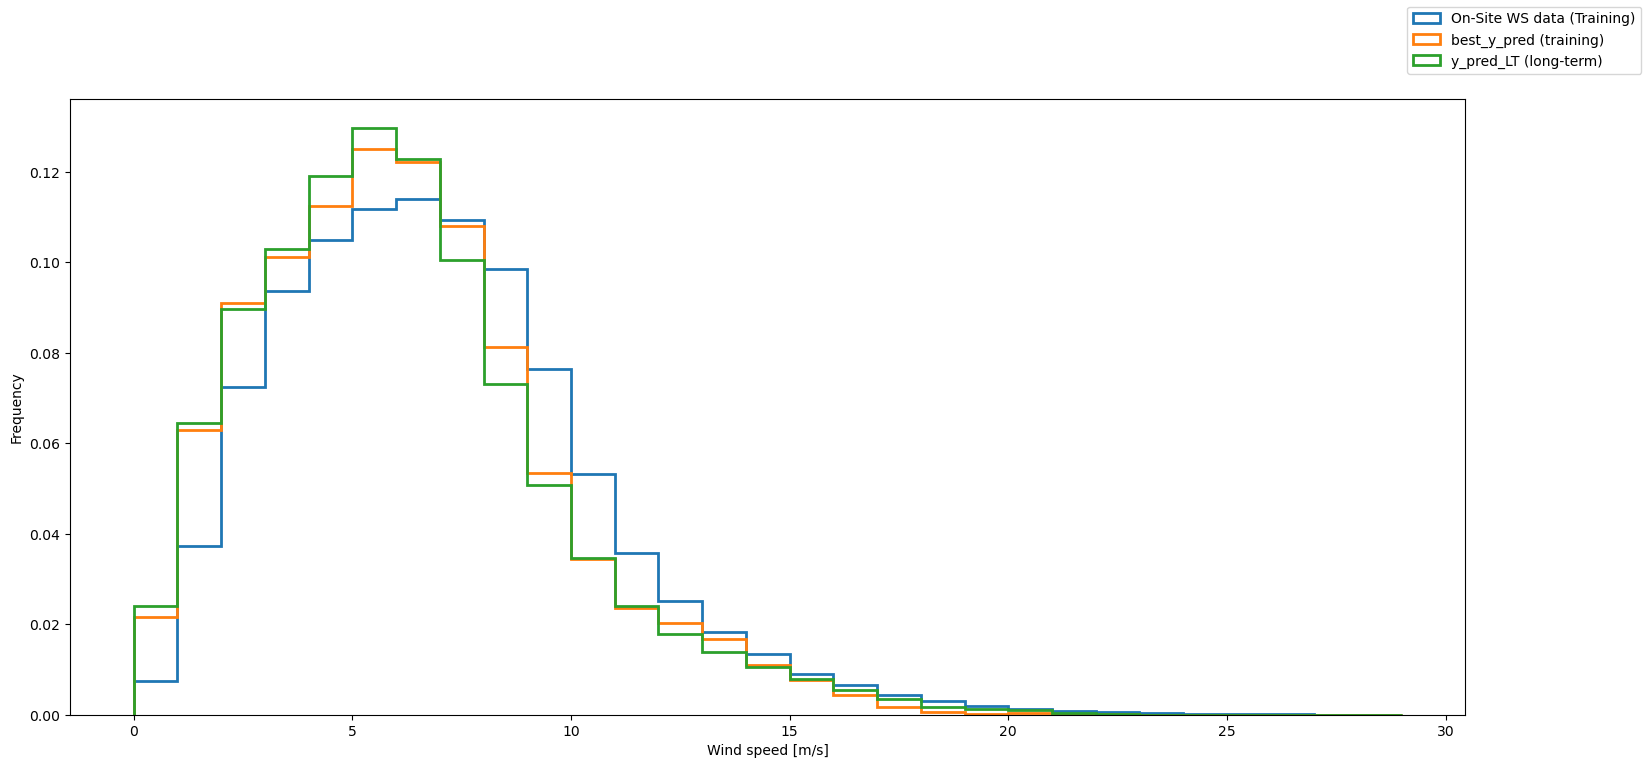

In [24]:
#Wind speed
fig, ax = plt.subplots(figsize=(18, 8))
bins_0 = np.arange(0.0, 30,1)
ax.hist(onsite_data[o_wsnode],bins=bins_0, density = True, histtype='step', lw = 2, label='On-Site WS data (Training)')
ax.hist(y_predict_train[o_wsnode+'_Predicted'],bins=bins_0, density = True, histtype='step', lw = 2, label='best_y_pred (training)')
ax.hist(WS_lt[o_wsnode],bins=bins_0, density = True, histtype='step', lw = 2, label='y_pred_LT (long-term)')

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels)
#plt.ylim(0,0.00002)
plt.xlabel('Wind speed [m/s]')
plt.ylabel('Frequency')
plt.show()

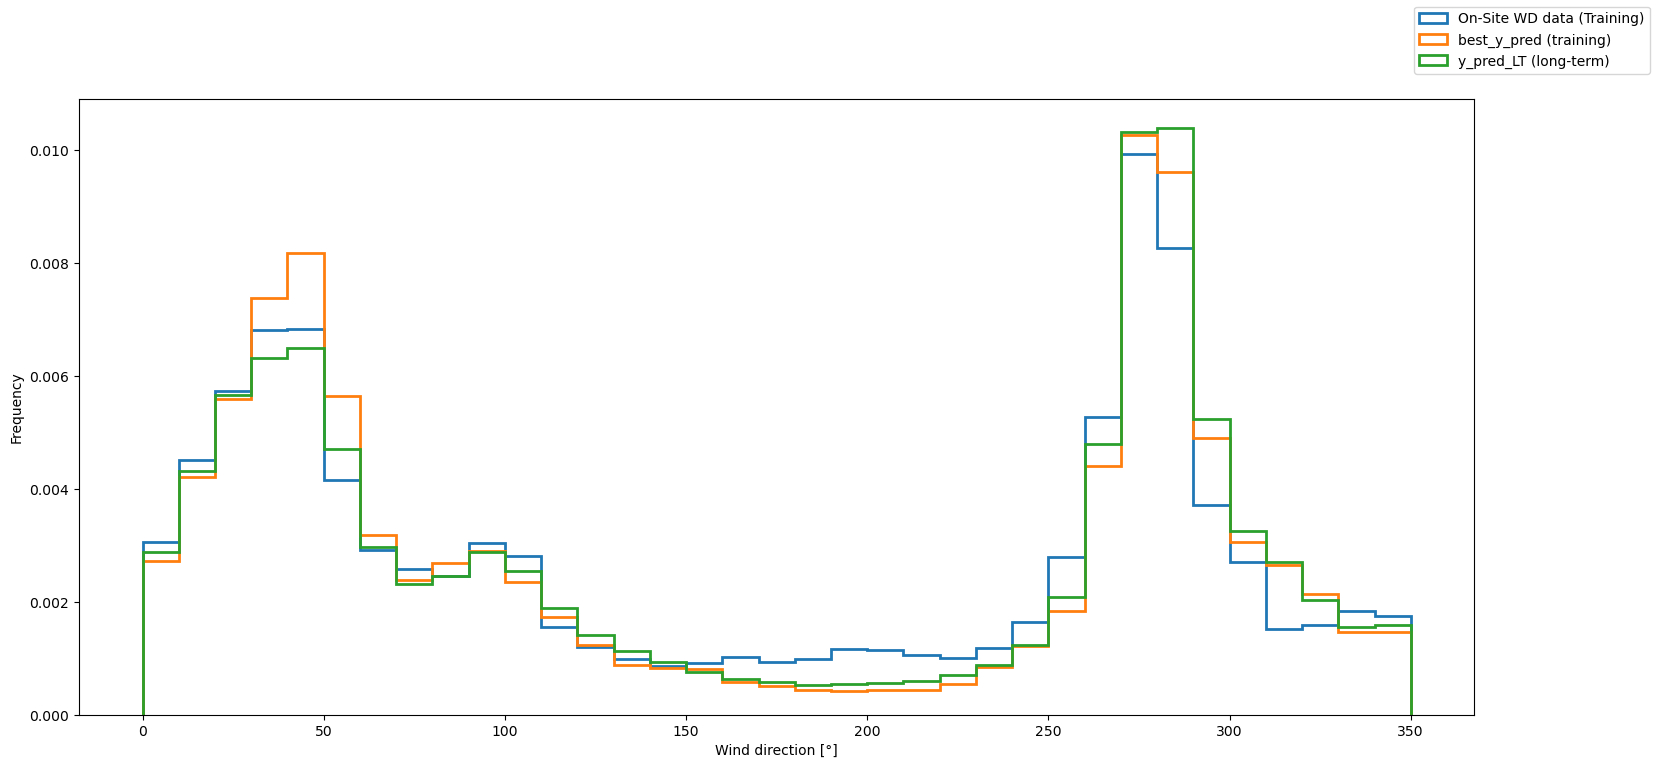

In [25]:
#Wind speed
fig, ax = plt.subplots(figsize=(18, 8))
bins_0 = np.arange(0.0, 360,10)
ax.hist(onsite_data[o_wdnode],bins=bins_0, density = True, histtype='step', lw = 2, label='On-Site WD data (Training)')
ax.hist(y_predict_train[o_wdnode+'_Predicted'],bins=bins_0, density = True, histtype='step', lw = 2, label='best_y_pred (training)')
ax.hist(WS_lt[o_wdnode],bins=bins_0, density = True, histtype='step', lw = 2, label='y_pred_LT (long-term)')

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels)
#plt.ylim(0,0.00002)
plt.xlabel('Wind direction [°]')
plt.ylabel('Frequency')
plt.show()

## Monthly/hourly profiles

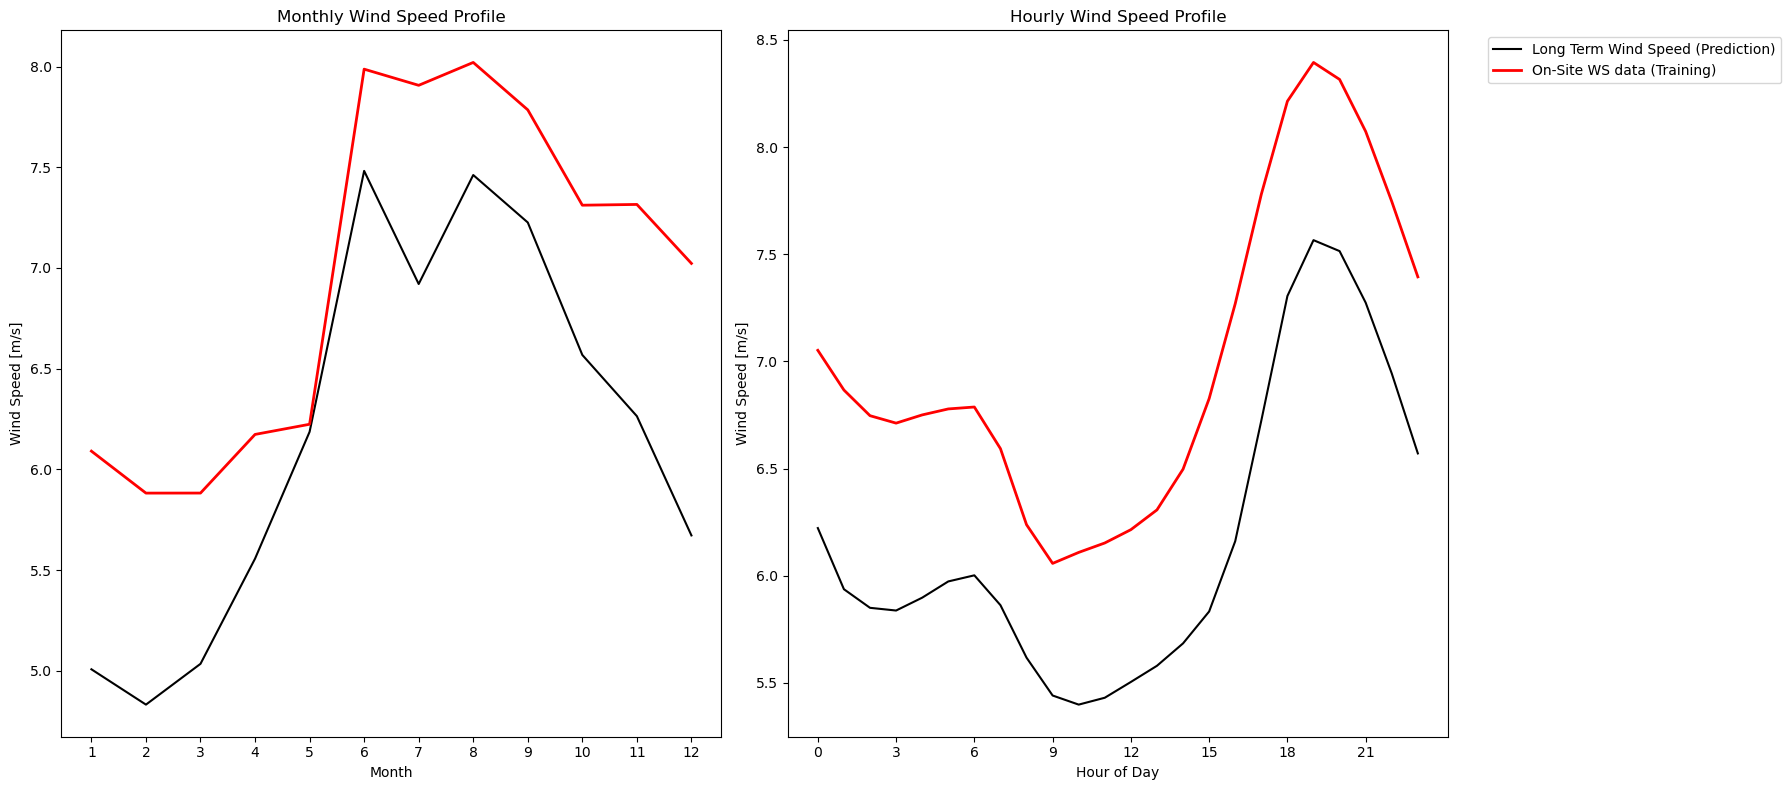

In [26]:
# binning of original PTS
# Visualise monthly and hourly wind speed profiles

# Use only wind speed columns for plotting (e.g., o_wsnode for onsite, 'M(m/s)' for reference, and WS_lt for prediction)
onsite_month = onsite_data.groupby(onsite_data.index.month).mean()[o_wsnode]
onsite_hour = onsite_data.groupby(onsite_data.index.hour).mean()[o_wsnode]
reference_month = vortex_data.groupby(vortex_data.index.month).mean()[v_wsnode]
reference_hour = vortex_data.groupby(vortex_data.index.hour).mean()[v_wsnode]
WS_lt_month = WS_lt.groupby(WS_lt.index.month).mean()[o_wsnode]
WS_lt_hour = WS_lt.groupby(WS_lt.index.hour).mean()[o_wsnode]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Monthly profile
ax[0].plot(WS_lt_month.index, WS_lt_month.values, 'k-', label='Long Term Wind Speed (Prediction)')
ax[0].plot(onsite_month.index, onsite_month.values, 'r-', lw=2, label='On-Site WS data (Training)')
ax[0].set_xlabel('Month')
ax[0].set_xticks(np.arange(1, 13, 1))
ax[0].set_ylabel('Wind Speed [m/s]')
ax[0].set_title('Monthly Wind Speed Profile')

# Hourly profile
ax[1].plot(WS_lt_hour.index, WS_lt_hour.values, 'k-', label='Long Term Wind Speed (Prediction)')
ax[1].plot(onsite_hour.index, onsite_hour.values, 'r-', lw=2, label='On-Site WS data (Training)')
ax[1].set_xlabel('Hour of Day')
ax[1].set_xticks(np.arange(0, 24, 3))
ax[1].set_ylabel('Wind Speed [m/s]')
ax[1].set_title('Hourly Wind Speed Profile')

# Combine legends
handles1, labels1 = ax[0].get_legend_handles_labels()
plt.legend(handles1, labels1 , loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## Annual Profile

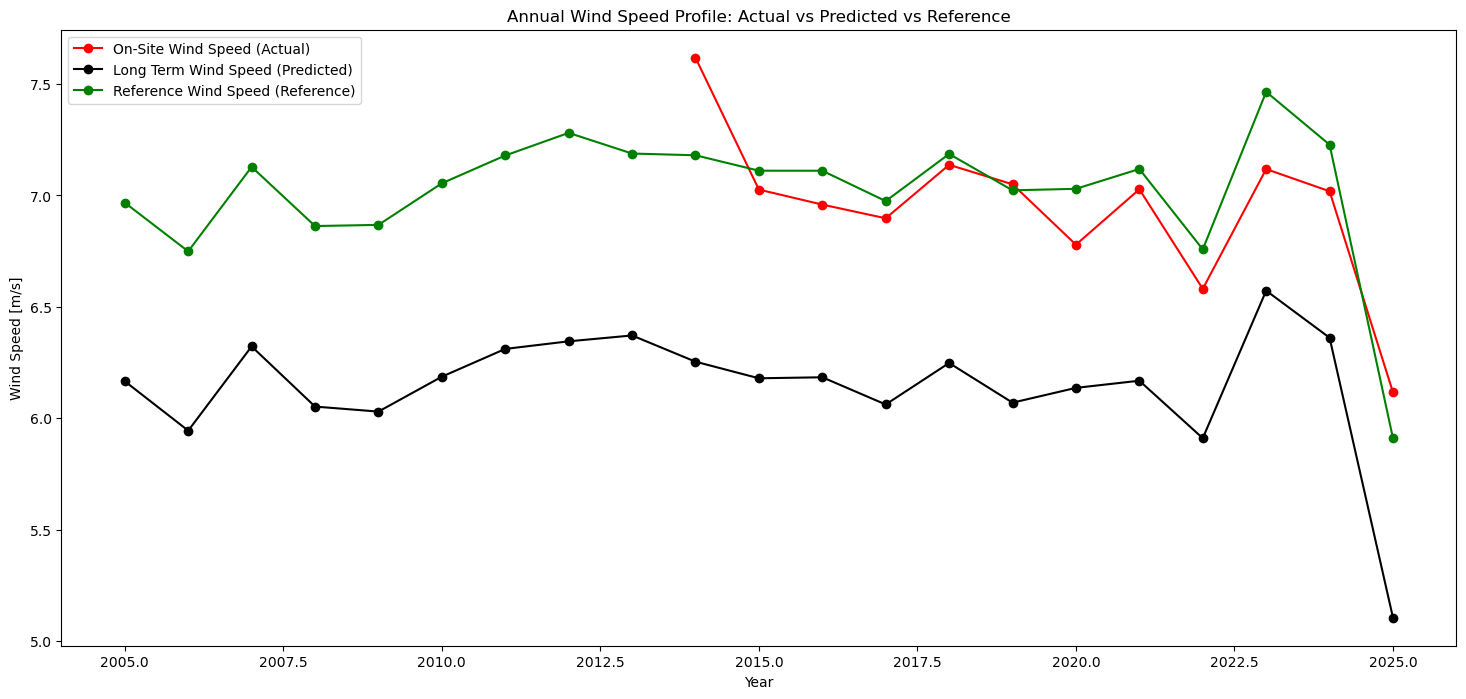

In [27]:
# Calculate annual mean wind speed for actual (onsite), predicted (WS_lt), and reference (Vortex) data
onsite_annual = onsite_data.groupby(onsite_data.index.year)[o_wsnode].mean()
predicted_annual = WS_lt.groupby(WS_lt.index.year)[o_wsnode].mean()
reference_annual = vortex_data.groupby(vortex_data.index.year)[v_wsnode].mean()

# Plot all three on the same figure
fig, ax = plt.subplots(figsize=(18, 8))
ax.plot(onsite_annual.index, onsite_annual.values, 'r-o', label='On-Site Wind Speed (Actual)')
ax.plot(predicted_annual.index, predicted_annual.values, 'k-o', label='Long Term Wind Speed (Predicted)')
ax.plot(reference_annual.index, reference_annual.values, 'g-o', label='Reference Wind Speed (Reference)')
ax.set_xlabel('Year')
ax.set_ylabel('Wind Speed [m/s]')
ax.set_title('Annual Wind Speed Profile: Actual vs Predicted vs Reference')
ax.legend()
plt.show()


## FFT

C:\Users\Romain.Molins\AppData\Local\Temp\ipykernel_7972\2986291763.py:18: RuntimeWarning: divide by zero encountered in divide
  xf_hour = 1/xf/3600/24/(nb_sec_freq/100)
C:\Users\Romain.Molins\AppData\Local\Temp\ipykernel_7972\2986291763.py:25: RuntimeWarning: divide by zero encountered in divide
  xf_hour2 = 1/xf2/3600/24/6


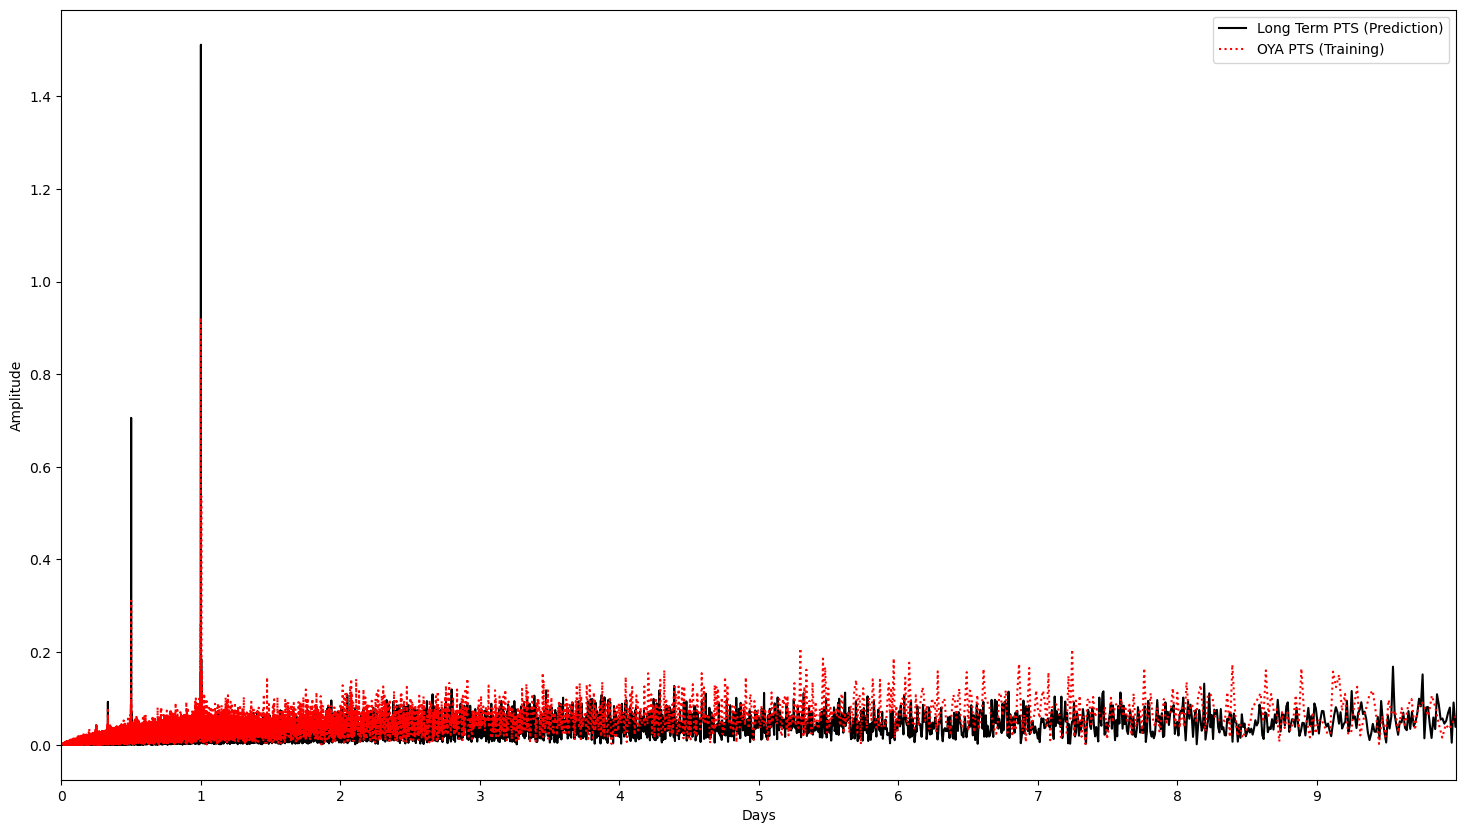

In [28]:
# Number of samplepoints
N2 = len(onsite_data)
N = len(WS_lt)

# sample spacing (in seconds)
T = 3600
# Calculate the FFT frequency step robustly
if WS_lt.index.freq is not None:
    nb_sec_freq = WS_lt.index.freq.delta.total_seconds()
else:
    # fallback: infer frequency from index if freq is None
    nb_sec_freq = (WS_lt.index[1] - WS_lt.index[0]).total_seconds()

#FFT of Synthesised data
y = WS_lt.iloc[:,0]
yf = scipy.fftpack.fft(y.values)
xf = np.linspace(0.0, 1.0/(2.0*T), int(N/2))
xf_hour = 1/xf/3600/24/(nb_sec_freq/100)

#FFT of Measured data
y2 = onsite_data[o_wsnode]
y2 = y2.fillna(0) #Replacing NaN by 0s
yf2 = scipy.fftpack.fft(y2.values)
xf2 = np.linspace(0.0, 1.0/(2.0*T), int(N2/2))
xf_hour2 = 1/xf2/3600/24/6

#Plot
fig, ax = plt.subplots(figsize=(18, 10))
ax.plot(xf_hour, 2.0/N * np.abs(yf[:N//2]), color = 'black', label='Long Term PTS (Prediction)' )
ax.plot(xf_hour2, 2.0/N2 * np.abs(yf2[:N2//2]), color = 'red',linestyle=':', label='OYA PTS (Training)')
ax.set_xlim(0,10)
ax.set_xticks(np.arange(0, 10, step=1))
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels)
ax.set_xlabel('Days')
ax.set_ylabel('Amplitude')

plt.show()

## LT Scaling Factor

In [76]:
print(f'Mean wind speed of onsite data during training period is {onsite_data.loc[start_training:end_training,o_wsnode].mean():.2f} m/s ')
print(f'Mean wind speed of predicted data during training period is {y_predict_train.loc[start_training:end_training,o_wsnode+'_Predicted'].mean():.2f} m/s ')
print(f'Mean wind speed of predicted data during long-term period is {WS_lt.loc[:,o_wsnode].mean():.2f} m/s ')
print(f'LT scaling factor is {100*((WS_lt.loc[:,o_wsnode].mean()/y_predict_train.loc[start_training:end_training,o_wsnode+'_Predicted'].mean())-1):.2f}% ')


Mean wind speed of onsite data during training period is 6.96 m/s 
Mean wind speed of predicted data during training period is 6.20 m/s 
Mean wind speed of predicted data during long-term period is 6.17 m/s 
LT scaling factor is -0.50% 


# Quantile Mapping

## Empirical Quantile Mapping Model

### Wind speed

In [29]:
#copy df for EQM
onsite_data_eqm = onsite_data.copy()
y_predict_train_eqm = y_predict_train.copy()
WS_lt_eqm = WS_lt.copy()

#edit index name
onsite_data_eqm.index.names = ['time1']
y_predict_train_eqm.index.names = ['time2']
WS_lt_eqm.index.names = ['time3']

#edit index type
onsite_data_eqm.index = onsite_data_eqm.index.tz_localize(None)
y_predict_train_eqm.index = y_predict_train_eqm.index.tz_localize(None)
WS_lt_eqm.index = WS_lt_eqm.index.tz_localize(None)

obsh = onsite_data_eqm.to_xarray()
simh = y_predict_train_eqm.rename(columns={o_wsnode+'_Predicted': o_wsnode, o_wdnode+'_Predicted': o_wdnode}).to_xarray()
simp = WS_lt_eqm.to_xarray()


In [30]:
variable = o_wsnode

WS_lt_eqm_adj = adjust(
    method="quantile_mapping",
    obs=obsh[variable],
    simh=simh[variable],
    simp=simp[variable],
    input_core_dims={"obs": "time1", "simh": "time2", "simp": "time3"},
    n_quantiles=60,
    kind="+",
).to_dataframe()

#postprocessing back to normal
WS_lt_eqm_adj.index = WS_lt_eqm_adj.index.tz_localize(time_zone_site)
WS_lt_eqm_adj.index.name = WS_lt.index.name
WS_lt_eqm_adj

,Speed 100m cmb [m/s]
YYYYMMDD_HHMM,
2005-01-01 02:00:00-02:00,7.796421
2005-01-01 02:10:00-02:00,7.274279
2005-01-01 02:20:00-02:00,6.677617
2005-01-01 02:30:00-02:00,6.430095
2005-01-01 02:40:00-02:00,7.428481
...,...
2025-05-30 23:10:00-02:00,6.249886
2025-05-30 23:20:00-02:00,6.268115
2025-05-30 23:30:00-02:00,6.466530


### Wind direction

In [31]:
variable = o_wdnode

WS_lt_eqm_adj_wd = adjust(
    method="quantile_mapping",
    obs=obsh[variable],
    simh=simh[variable],
    simp=simp[variable],
    input_core_dims={"obs": "time1", "simh": "time2", "simp": "time3"},
    n_quantiles=60,
    kind="+",
).to_dataframe()

#postprocessing back to normal
WS_lt_eqm_adj_wd.index = WS_lt_eqm_adj_wd.index.tz_localize(time_zone_site)
WS_lt_eqm_adj_wd.index.name = WS_lt.index.name
WS_lt_eqm_adj_wd

,Wind Direction 97.90m S avg [°]
YYYYMMDD_HHMM,
2005-01-01 02:00:00-02:00,105.869241
2005-01-01 02:10:00-02:00,104.823464
2005-01-01 02:20:00-02:00,98.192749
2005-01-01 02:30:00-02:00,99.729332
2005-01-01 02:40:00-02:00,100.601188
...,...
2025-05-30 23:10:00-02:00,18.944670
2025-05-30 23:20:00-02:00,13.525468
2025-05-30 23:30:00-02:00,8.970588


In [32]:
#post process for validation
WS_lt_eqm_adj = WS_lt_eqm_adj.merge(WS_lt_eqm_adj_wd, left_index=True, right_index=True)

data_predict_train_eqm_adj = WS_lt_eqm_adj.loc[start_training:end_training,columnsY_ps].merge(onsite_data.loc[start_training:end_training,columnsY_ps],how='inner',left_index=True, right_index=True,suffixes= ('_Predicted', '_Original') )
data_predict_train_eqm_adj.dropna(inplace=True)
y_predict_train_eqm_adj = data_predict_train_eqm_adj.loc[start_training:end_training,[l + '_Predicted' for l in columnsY_ps]].copy()
y_predict_train_eqm_adj

,Speed 100m cmb [m/s]_Predicted,Wind Direction 97.90m S avg [°]_Predicted
YYYYMMDD_HHMM,,
2016-01-01 00:00:00-02:00,6.666984,24.106412
2016-01-01 00:10:00-02:00,6.245027,24.610723
2016-01-01 00:20:00-02:00,6.462119,22.622707
2016-01-01 00:30:00-02:00,6.186536,23.065757
2016-01-01 00:40:00-02:00,6.274525,18.468288
...,...,...
2016-12-31 23:10:00-02:00,6.866881,11.082352
2016-12-31 23:20:00-02:00,6.869229,12.638758
2016-12-31 23:30:00-02:00,6.753656,7.333727


In [33]:
data_predict_test_eqm_adj = WS_lt_eqm_adj.loc[start_testing:end_testing,columnsY_ps].merge(onsite_data.loc[start_testing:end_testing,columnsY_ps],how='inner',left_index=True, right_index=True,suffixes= ('_Predicted', '_Original') )
data_predict_test_eqm_adj.dropna(inplace=True)
y_predict_test_eqm_adj = data_predict_test_eqm_adj.loc[start_testing:end_testing,[l + '_Predicted' for l in columnsY_ps]].copy()
y_predict_test_eqm_adj

,Speed 100m cmb [m/s]_Predicted,Wind Direction 97.90m S avg [°]_Predicted
YYYYMMDD_HHMM,,
2017-01-01 00:00:00-02:00,5.569477,4.398080
2017-01-01 00:10:00-02:00,4.948628,357.690099
2017-01-01 00:20:00-02:00,4.305646,347.087948
2017-01-01 00:30:00-02:00,4.304520,337.575286
2017-01-01 00:40:00-02:00,3.669054,331.760499
...,...,...
2017-12-31 19:30:00-02:00,7.374618,19.775076
2017-12-31 19:40:00-02:00,7.670528,11.433665
2017-12-31 19:50:00-02:00,7.473678,8.991129


## Scores

In [34]:
#we give example of both error values using the previous baseline models
overall_score_best = overall_score(y_test[o_wsnode].to_numpy(), y_predict_test_eqm_adj[o_wsnode+'_Predicted'].to_numpy())
binned_error_best = binned_error(y_test[o_wsnode].to_numpy(), y_predict_test_eqm_adj[o_wsnode+'_Predicted'].to_numpy())
best_score_best = 100 * sqrt(mean_squared_error(y_test[o_wsnode], y_predict_test_eqm_adj[o_wsnode+'_Predicted'])) / y_test[o_wsnode].max()
print(f'Score is {best_score_best:.2f}% ')
print(f'Binned error is {100*binned_error_best:.2f}% ')
print(f'Overall error is  {100*overall_score_best:.2f}% ')

Score is 7.60% 
Binned error is 0.16% 
Overall error is  7.76% 


In [35]:
#we give example of both error values using the previous baseline models
overall_score_best = overall_score(y_test[o_wdnode].to_numpy(), y_predict_test_eqm_adj[o_wdnode+'_Predicted'].to_numpy())
binned_error_best = binned_error(y_test[o_wdnode].to_numpy(), y_predict_test_eqm_adj[o_wdnode+'_Predicted'].to_numpy())
best_score_best = 100 * sqrt(mean_squared_error(y_test[o_wdnode], y_predict_test_eqm_adj[o_wdnode+'_Predicted'])) / y_test[o_wdnode].max()
print(f'Score is {best_score_best:.2f}% ')
print(f'Binned error is {100*binned_error_best:.2f}% ')
print(f'Overall error is  {100*overall_score_best:.2f}% ')

Score is 24.95% 
Binned error is 0.05% 
Overall error is  24.99% 


## Histogram check

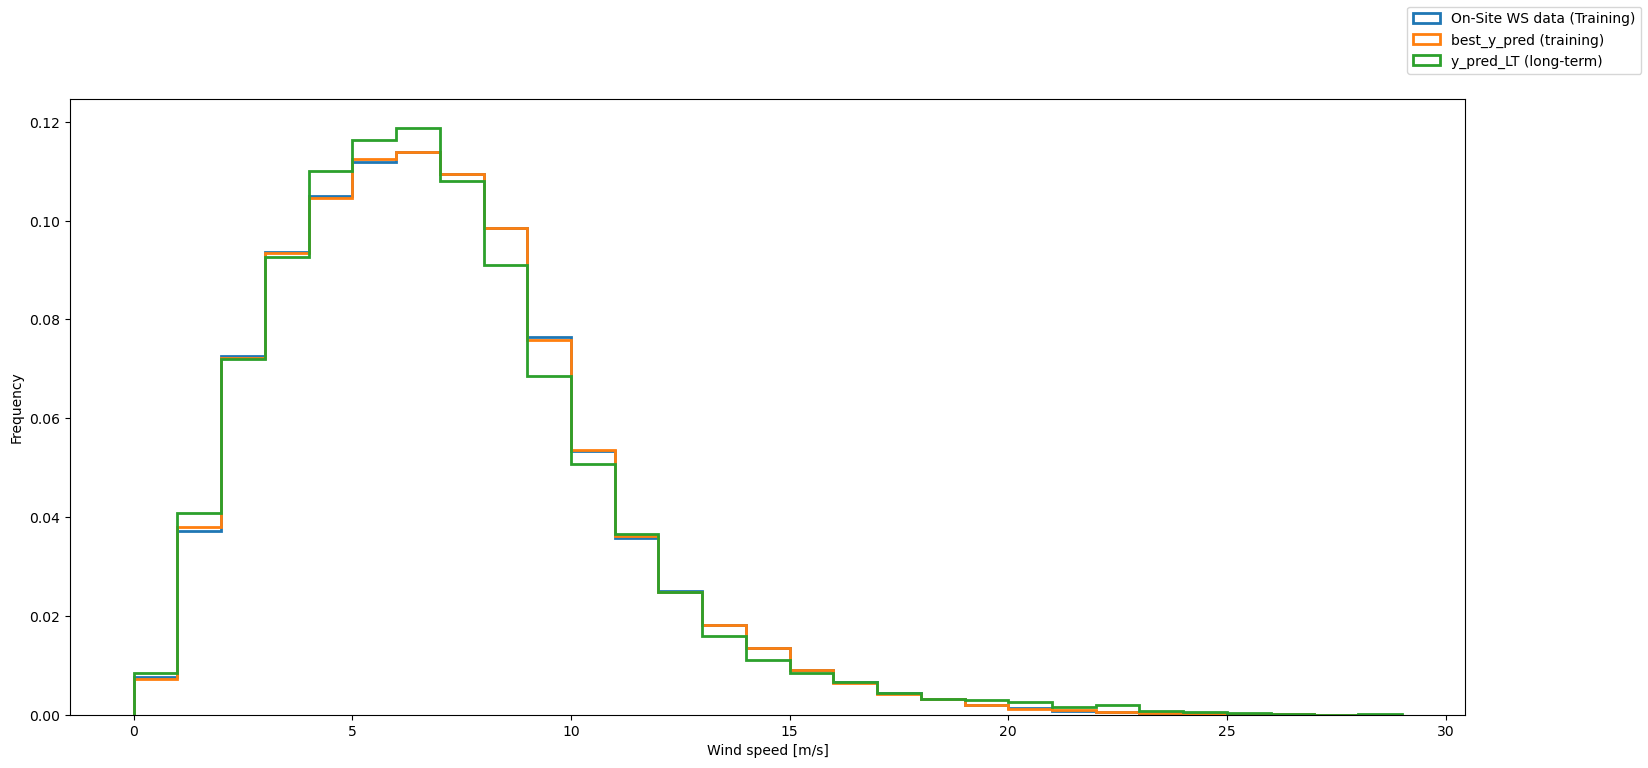

In [36]:
#Wind speed
fig, ax = plt.subplots(figsize=(18, 8))
bins_0 = np.arange(0.0, 30, 1)
ax.hist(onsite_data[o_wsnode],bins=bins_0, density = True, histtype='step', lw = 2, label='On-Site WS data (Training)')
ax.hist(y_predict_train_eqm_adj[o_wsnode+'_Predicted'],bins=bins_0, density = True, histtype='step', lw = 2, label='best_y_pred (training)')
ax.hist(WS_lt_eqm_adj[o_wsnode],bins=bins_0, density = True, histtype='step', lw = 2, label='y_pred_LT (long-term)')

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels)
#plt.ylim(0,0.00002)
plt.xlabel('Wind speed [m/s]')
plt.ylabel('Frequency')
plt.show()

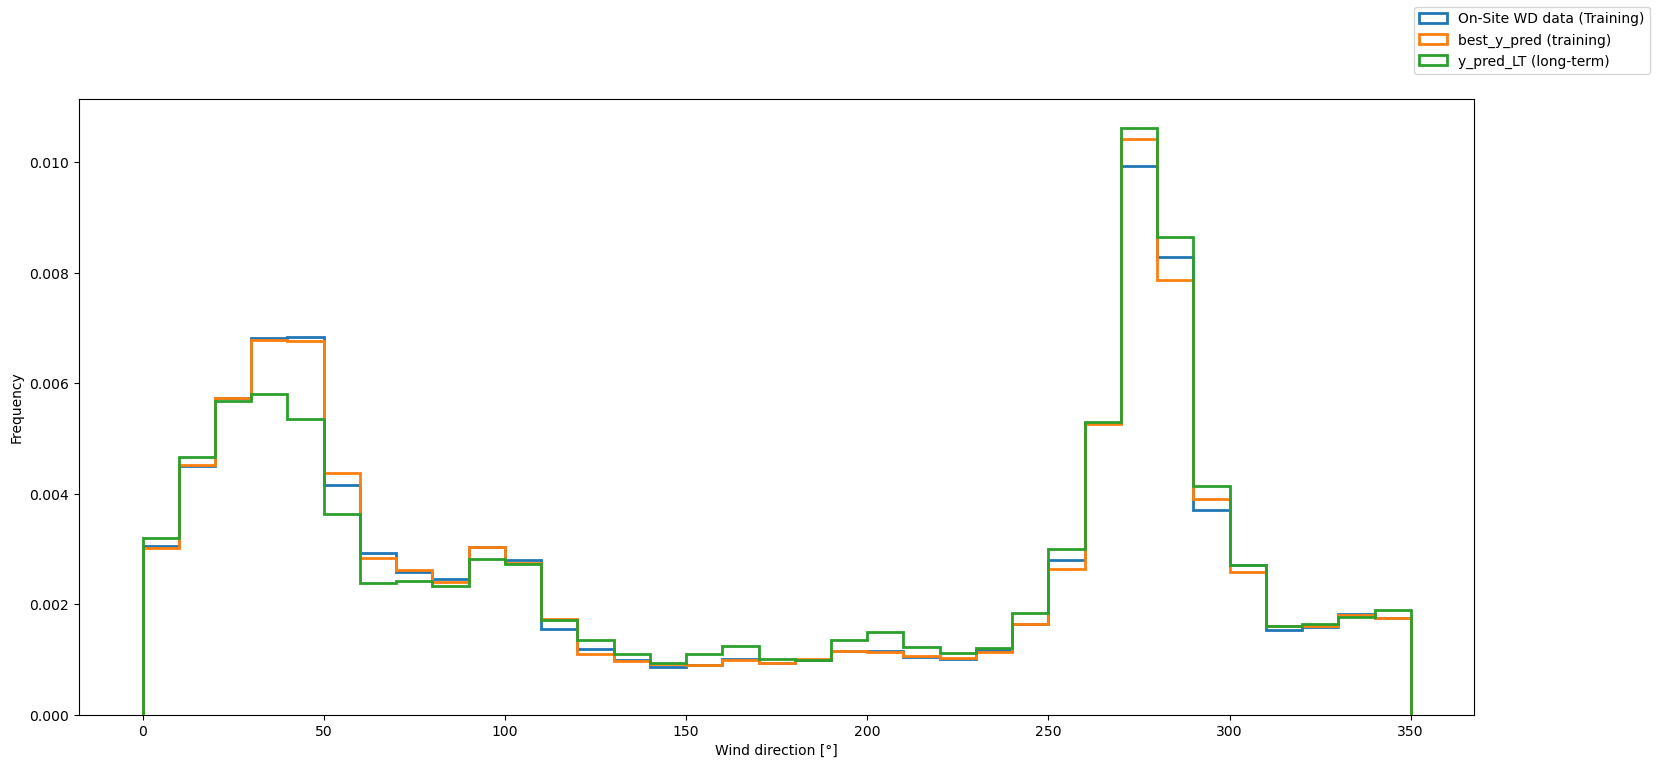

In [37]:
#Wind direction
fig, ax = plt.subplots(figsize=(18, 8))
bins_0 = np.arange(0.0, 360, 10)
ax.hist(onsite_data[o_wdnode],bins=bins_0, density = True, histtype='step', lw = 2, label='On-Site WD data (Training)')
ax.hist(y_predict_train_eqm_adj[o_wdnode+'_Predicted'],bins=bins_0, density = True, histtype='step', lw = 2, label='best_y_pred (training)')
ax.hist(WS_lt_eqm_adj[o_wdnode],bins=bins_0, density = True, histtype='step', lw = 2, label='y_pred_LT (long-term)')

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels)
#plt.ylim(0,0.00002)
plt.xlabel('Wind direction [°]')
plt.ylabel('Frequency')
plt.show()

## Scatterplot check

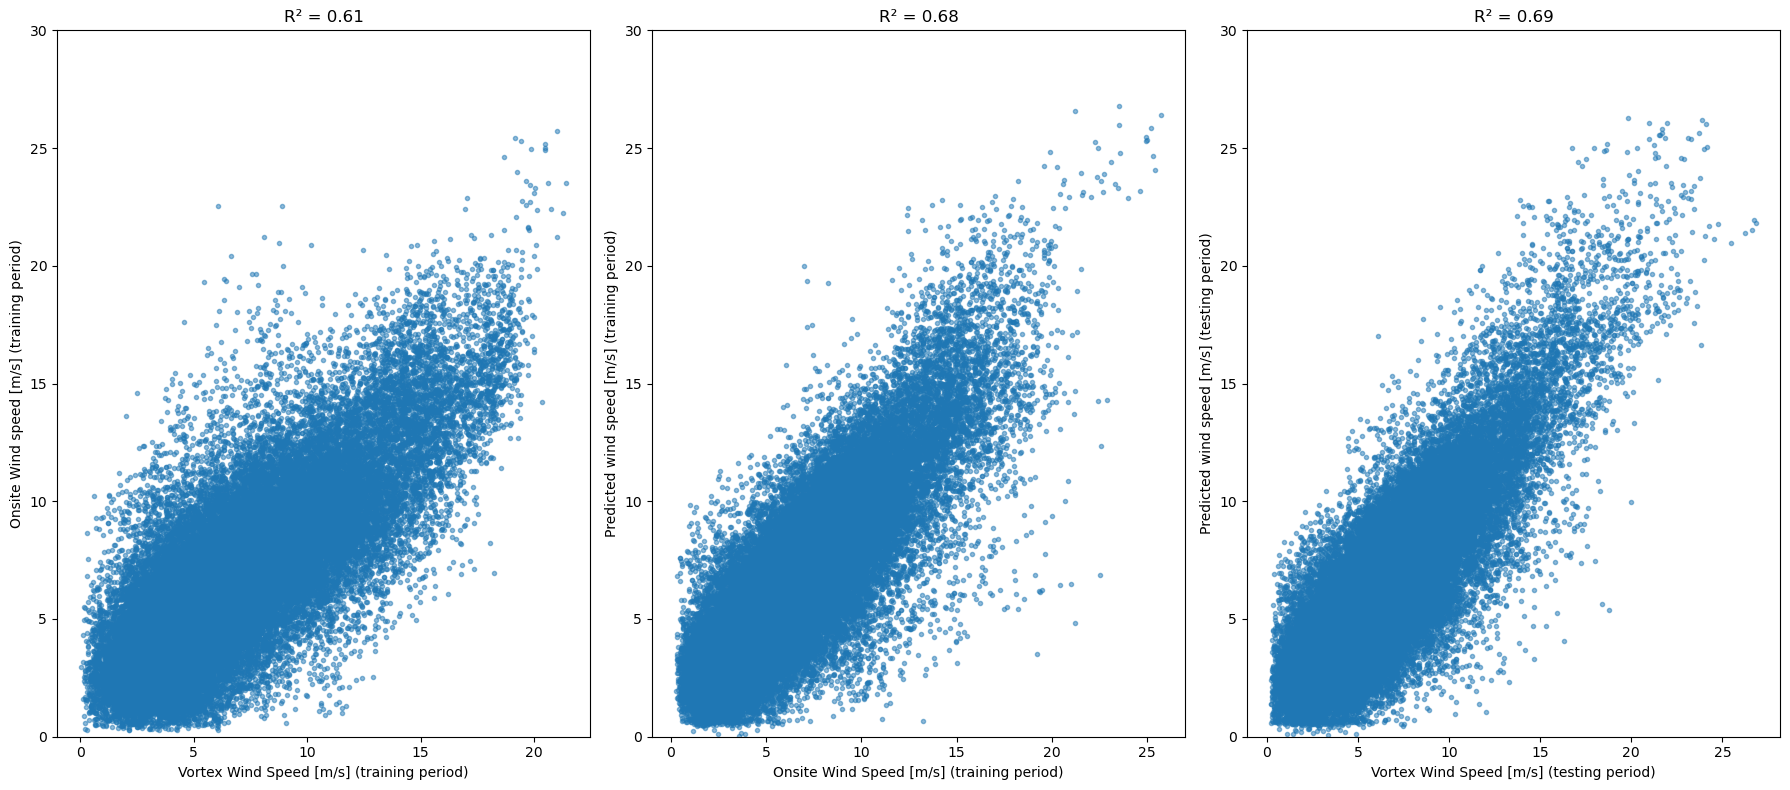

In [38]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 8))

ylim = (0, 30)

# 1st plot: ws vs y_train
#r2_score is not equal to pearson squared for any fit that is non linear!
#r2_1 = r2_score(data_train['ws scaled'], data_train[o_wsnode])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_train[v_wsnode], data_train[o_wsnode])
r2_1 = r_value**2

ax[0].scatter(data_train[v_wsnode], data_train[o_wsnode], marker='.', alpha=0.5)
ax[0].set_xlabel('Vortex Wind Speed [m/s] (training period)')
ax[0].set_ylabel('Onsite Wind speed [m/s] (training period)')
ax[0].set_ylim(*ylim)
ax[0].set_title(f'R² = {r2_1:.2f}')

# 2nd plot: ws vs best_y_pred
#r2_2 = r2_score(data_predict_train.iloc[:,0], data_predict_train.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_train[o_wsnode+'_Original'], data_predict_train[o_wsnode+'_Predicted'])
r2_2 = r_value**2

ax[1].scatter(data_predict_train_eqm_adj[o_wsnode+'_Original'],data_predict_train_eqm_adj[o_wsnode+'_Predicted'], marker='.', alpha=0.5)
ax[1].set_xlabel('Onsite Wind Speed [m/s] (training period)')
ax[1].set_ylabel('Predicted wind speed [m/s] (training period)')
ax[1].set_ylim(*ylim)
ax[1].set_title(f'R² = {r2_2:.2f}')


# 3nd plot: test period
#r2_3 = r2_score(data_predict_test.iloc[:,0], data_predict_test.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_test[o_wsnode+'_Original'], data_predict_test[o_wsnode+'_Predicted'])
r2_3 = r_value**2

ax[2].scatter(data_predict_test_eqm_adj[o_wsnode+'_Original'], data_predict_test_eqm_adj[o_wsnode+'_Predicted'], marker='.', alpha=0.5)
ax[2].set_xlabel('Vortex Wind Speed [m/s] (testing period)')
ax[2].set_ylabel('Predicted wind speed [m/s] (testing period)')
ax[2].set_ylim(*ylim)
ax[2].set_title(f'R² = {r2_3:.2f}')


plt.tight_layout()
plt.show()

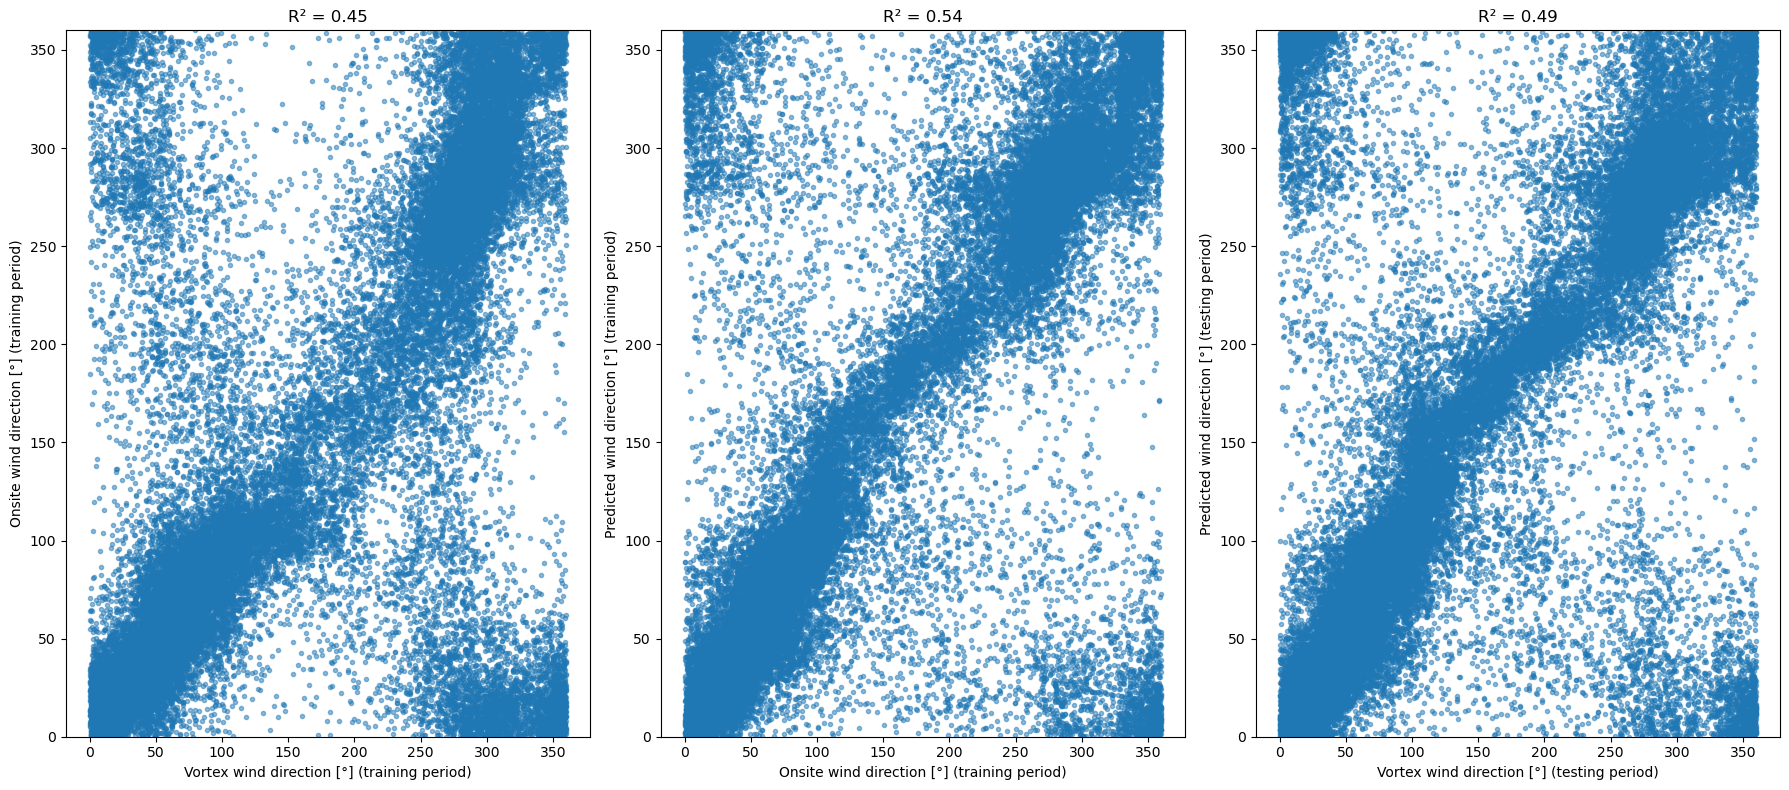

In [39]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 8))

ylim = (0, 360)

# 1st plot: ws vs y_train
#r2_score is not equal to pearson squared for any fit that is non linear!
#r2_1 = r2_score(data_train['ws scaled'], data_train[o_wdnode])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_train[v_wdnode], data_train[o_wdnode])
r2_1 = r_value**2

ax[0].scatter(data_train[v_wdnode], data_train[o_wdnode], marker='.', alpha=0.5)
ax[0].set_xlabel('Vortex wind direction [°] (training period)')
ax[0].set_ylabel('Onsite wind direction [°] (training period)')
ax[0].set_ylim(*ylim)
ax[0].set_title(f'R² = {r2_1:.2f}')

# 2nd plot: ws vs best_y_pred
#r2_2 = r2_score(data_predict_train.iloc[:,0], data_predict_train.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_train[o_wdnode+'_Original'], data_predict_train[o_wdnode+'_Predicted'])
r2_2 = r_value**2

ax[1].scatter(data_predict_train_eqm_adj[o_wdnode+'_Original'],data_predict_train_eqm_adj[o_wdnode+'_Predicted'], marker='.', alpha=0.5)
ax[1].set_xlabel('Onsite wind direction [°] (training period)')
ax[1].set_ylabel('Predicted wind direction [°] (training period)')
ax[1].set_ylim(*ylim)
ax[1].set_title(f'R² = {r2_2:.2f}')


# 3nd plot: test period
#r2_3 = r2_score(data_predict_test.iloc[:,0], data_predict_test.iloc[:,1])
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(data_predict_test[o_wdnode+'_Original'], data_predict_test[o_wdnode+'_Predicted'])
r2_3 = r_value**2

ax[2].scatter(data_predict_test_eqm_adj[o_wdnode+'_Original'], data_predict_test_eqm_adj[o_wdnode+'_Predicted'], marker='.', alpha=0.5)
ax[2].set_xlabel('Vortex wind direction [°] (testing period)')
ax[2].set_ylabel('Predicted wind direction [°] (testing period)')
ax[2].set_ylim(*ylim)
ax[2].set_title(f'R² = {r2_3:.2f}')


plt.tight_layout()
plt.show()

## Monthly/hourly profiles

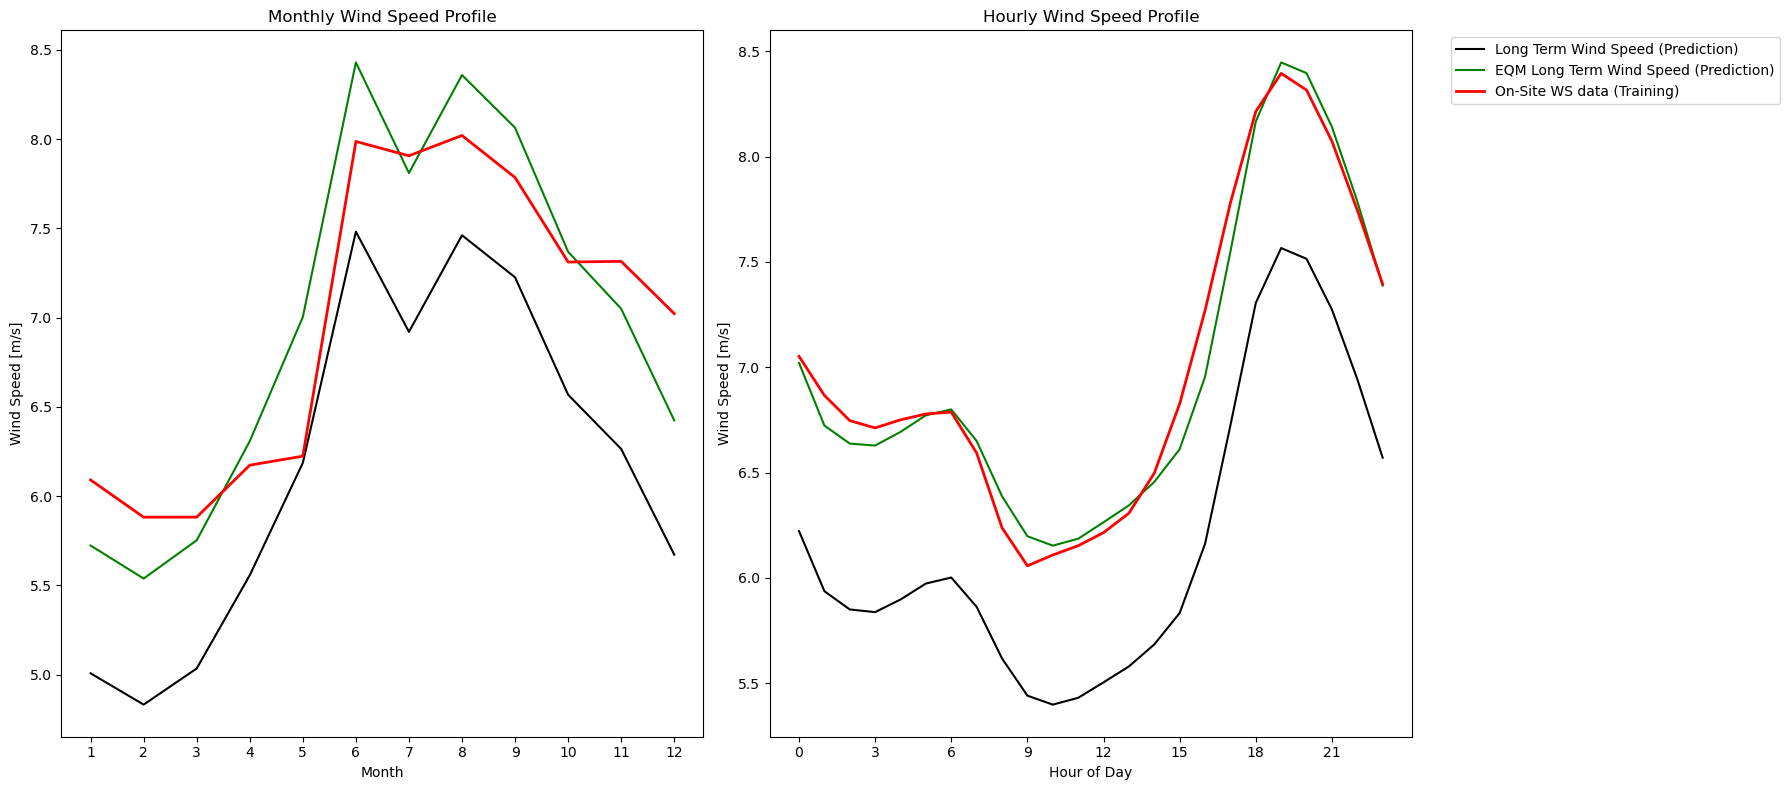

In [40]:
# binning of original PTS
# Visualise monthly and hourly wind speed profiles

# Use only wind speed columns for plotting (e.g., o_wsnode for onsite, 'M(m/s)' for reference, and WS_lt for prediction)
WS_lt_month_eqm_adj = WS_lt_eqm_adj.groupby(WS_lt.index.month).mean()[o_wsnode]
WS_lt_hour_eqm_adj = WS_lt_eqm_adj.groupby(WS_lt.index.hour).mean()[o_wsnode]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Monthly profile
ax[0].plot(WS_lt_month.index, WS_lt_month.values, 'k-', label='Long Term Wind Speed (Prediction)')
ax[0].plot(WS_lt_month_eqm_adj.index, WS_lt_month_eqm_adj.values, 'g-', label='EQM Long Term Wind Speed (Prediction)')
ax[0].plot(onsite_month.index, onsite_month.values, 'r-', lw=2, label='On-Site WS data (Training)')
ax[0].set_xlabel('Month')
ax[0].set_xticks(np.arange(1, 13, 1))
ax[0].set_ylabel('Wind Speed [m/s]')
ax[0].set_title('Monthly Wind Speed Profile')

# Hourly profile
ax[1].plot(WS_lt_hour.index, WS_lt_hour.values, 'k-', label='Long Term Wind Speed (Prediction)')
ax[1].plot(WS_lt_hour_eqm_adj.index, WS_lt_hour_eqm_adj.values, 'g-', label='EQM Long Term Wind Speed (Prediction)')
ax[1].plot(onsite_hour.index, onsite_hour.values, 'r-', lw=2, label='On-Site WS data (Training)')
ax[1].set_xlabel('Hour of Day')
ax[1].set_xticks(np.arange(0, 24, 3))
ax[1].set_ylabel('Wind Speed [m/s]')
ax[1].set_title('Hourly Wind Speed Profile')

# Combine legends
handles1, labels1 = ax[0].get_legend_handles_labels()
plt.legend(handles1, labels1 , loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## FFT

C:\Users\Romain.Molins\AppData\Local\Temp\ipykernel_7972\1831307535.py:18: RuntimeWarning: divide by zero encountered in divide
  xf_hour = 1/xf/3600/24/(nb_sec_freq/100)
C:\Users\Romain.Molins\AppData\Local\Temp\ipykernel_7972\1831307535.py:25: RuntimeWarning: divide by zero encountered in divide
  xf_hour2 = 1/xf2/3600/24/6


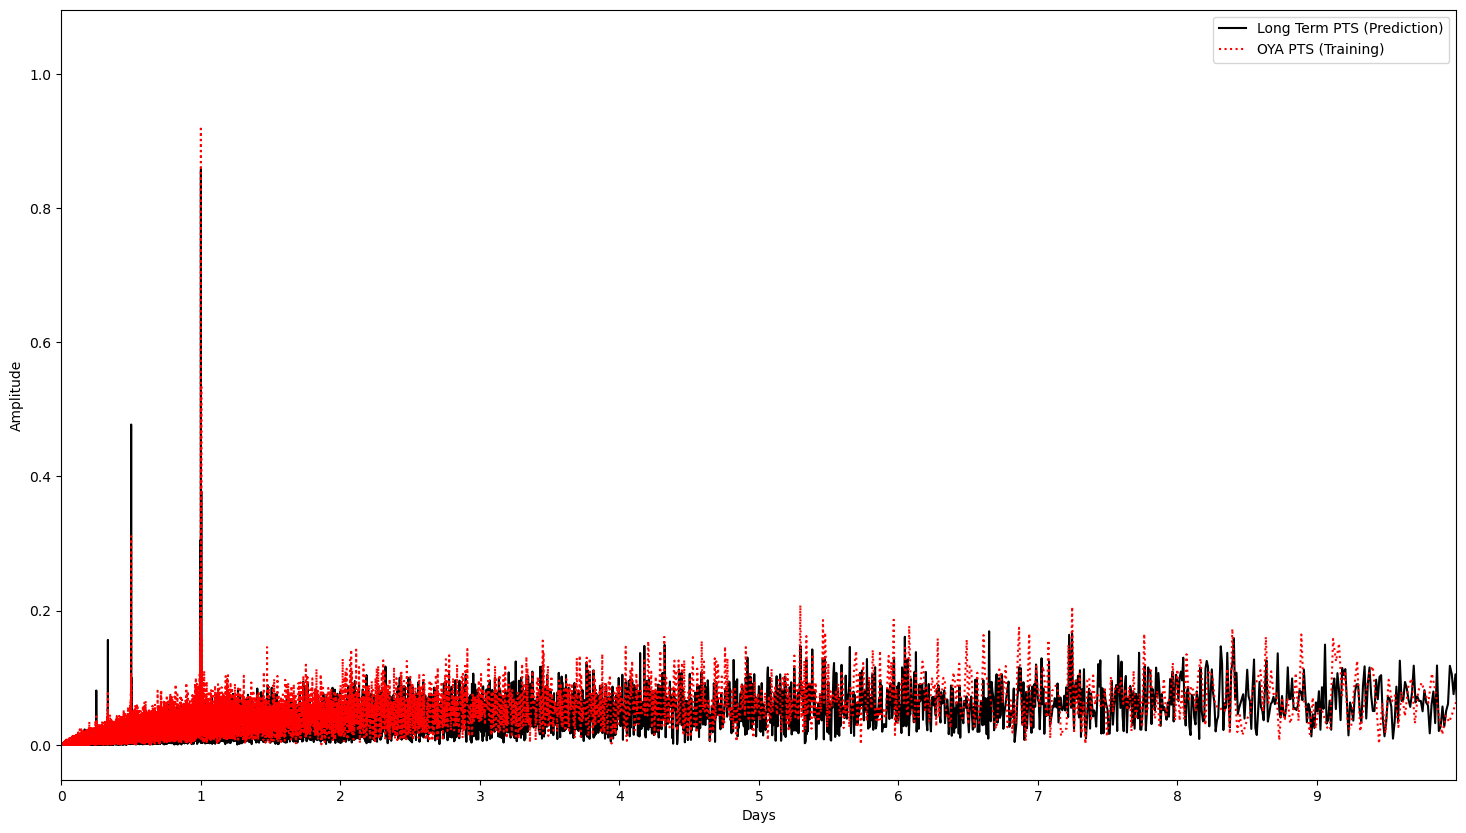

In [41]:
# Number of samplepoints
N2 = len(onsite_data)
N = len(WS_lt_eqm_adj)

# sample spacing (in seconds)
T = 3600
# Calculate the FFT frequency step robustly
if WS_lt_eqm_adj.index.freq is not None:
    nb_sec_freq = WS_lt_eqm_adj.index.freq.delta.total_seconds()
else:
    # fallback: infer frequency from index if freq is None
    nb_sec_freq = (WS_lt_eqm_adj.index[1] - WS_lt_eqm_adj.index[0]).total_seconds()

#FFT of Synthesised data
y = WS_lt_eqm_adj.iloc[:,0]
yf = scipy.fftpack.fft(y.values)
xf = np.linspace(0.0, 1.0/(2.0*T), int(N/2))
xf_hour = 1/xf/3600/24/(nb_sec_freq/100)

#FFT of Measured data
y2 = onsite_data[o_wsnode]
y2 = y2.fillna(0) #Replacing NaN by 0s
yf2 = scipy.fftpack.fft(y2.values)
xf2 = np.linspace(0.0, 1.0/(2.0*T), int(N2/2))
xf_hour2 = 1/xf2/3600/24/6

#Plot
fig, ax = plt.subplots(figsize=(18, 10))
ax.plot(xf_hour, 2.0/N * np.abs(yf[:N//2]), color = 'black', label='Long Term PTS (Prediction)' )
ax.plot(xf_hour2, 2.0/N2 * np.abs(yf2[:N2//2]), color = 'red',linestyle=':', label='OYA PTS (Training)')
ax.set_xlim(0,10)
ax.set_xticks(np.arange(0, 10, step=1))
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels)
ax.set_xlabel('Days')
ax.set_ylabel('Amplitude')

plt.show()

## Scaling factor

In [77]:
print(f'Mean wind speed of onsite data during training period is {onsite_data.loc[start_training:end_training,o_wsnode].mean():.2f} m/s ')
print(f'Mean wind speed of predicted data during training period is {y_predict_train_eqm_adj.loc[start_training:end_training,o_wsnode+'_Predicted'].mean():.2f} m/s ')
print(f'Mean wind speed of predicted data during long-term period is {WS_lt_eqm_adj.loc[:,o_wsnode].mean():.2f} m/s ')
print(f'LT scaling factor is {100*((WS_lt_eqm_adj.loc[:,o_wsnode].mean()/y_predict_train_eqm_adj.loc[start_training:end_training,o_wsnode+'_Predicted'].mean())-1):.2f}% ')


Mean wind speed of onsite data during training period is 6.96 m/s 
Mean wind speed of predicted data during training period is 6.99 m/s 
Mean wind speed of predicted data during long-term period is 6.97 m/s 
LT scaling factor is -0.30% 
